# Beyond Accuracy: Heart Disease Classification on Imbalanced Survey Data

Predicting self-reported heart disease from behavioral, medical, and demographic
features in the CDC BRFSS 2020 survey, and showing why **accuracy is the wrong
metric** when the classes are imbalanced.

**The short version:** four standard classifiers all score ~89% accuracy, but none
beats a model that just predicts "no disease" for everyone, and they detect only
1.5%-15.2% of actual heart disease cases. Two standard fixes (class weighting and
decision-threshold tuning) recover most of that lost sensitivity, raising detection
to roughly two-thirds of cases. The signal was there the whole time; the default
0.5 threshold was hiding it.

**Dataset:** a 3,087-row subset of the [Personal Key Indicators of Heart Disease](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease)
dataset (derived from BRFSS 2020). Positive cases are 11.7% of records.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, classification_report,
)

RANDOM_STATE = 0
plt.rcParams["figure.figsize"] = (8, 6)

## 2. Load the data

In [2]:
heart_df = pd.read_csv("data/heart_2020_cleaned_edited.csv").dropna()

# Encode the target: Yes -> 1, No -> 0
heart_df["HeartDisease"] = heart_df["HeartDisease"].map({"Yes": 1, "No": 0})

print("Shape:", heart_df.shape)
print()
print(heart_df["HeartDisease"].value_counts())
print()
prevalence = heart_df["HeartDisease"].mean()
print(f"Positive-class prevalence: {prevalence:.3f}  ({heart_df['HeartDisease'].sum()} of {len(heart_df)})")

Shape: (3087, 18)

HeartDisease
0    2726
1     361
Name: count, dtype: int64

Positive-class prevalence: 0.117  (361 of 3087)


In [3]:
heart_df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,0,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,0,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,0,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,0,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


## 3. Preprocessing

Split predictors into continuous and categorical, one-hot encode the categorical
ones (dropping the first level of each to avoid redundancy), and recombine.


In [4]:
X = heart_df.drop(["HeartDisease"], axis=1)
y = heart_df["HeartDisease"]

categorical_cols = ["Race", "AgeCategory", "GenHealth", "Sex", "Smoking",
                    "AlcoholDrinking", "Stroke", "DiffWalking", "Diabetic",
                    "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]

numerical = X.drop(categorical_cols, axis=1)
categorical = X[categorical_cols]

cat_numerical = pd.get_dummies(categorical, drop_first=True)
X = pd.concat([numerical, cat_numerical], axis=1)

print("Feature matrix shape after encoding:", X.shape)
X.head()

Feature matrix shape after encoding: (3087, 37)


,BMI,PhysicalHealth,MentalHealth,SleepTime,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,AgeCategory_25-29,...,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,16.60,3,30,5,False,False,False,False,True,False,...,False,False,False,False,True,False,True,True,False,True
1,20.34,0,0,7,False,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,False
2,26.58,20,30,8,False,False,False,False,True,False,...,False,False,False,False,True,False,True,True,False,False
3,24.21,0,0,6,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,23.71,28,0,8,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False


### Quick correlation look (numeric features)

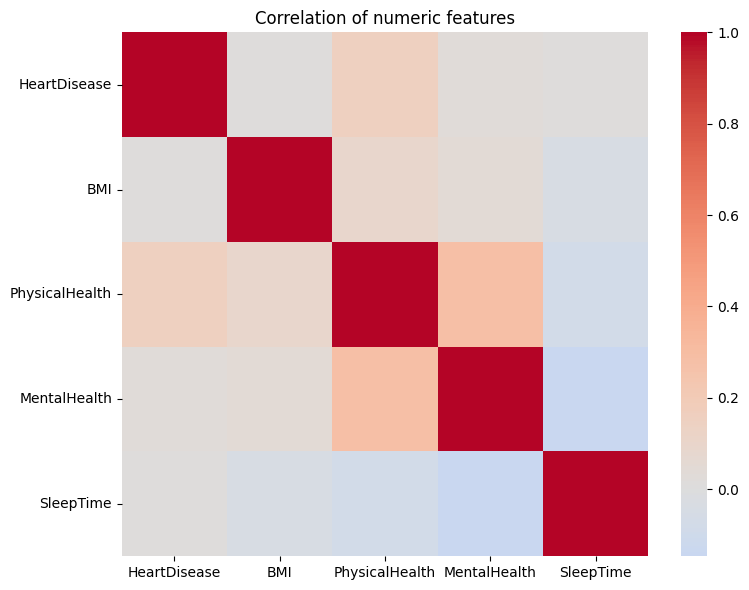

In [5]:
corr = heart_df._get_numeric_data().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation of numeric features")
plt.tight_layout()
plt.show()

## 4. Train / test split and scaling

80/20 split with a fixed seed. The scaler is fit on the training data only, then
applied to the test data, so no test information leaks into preprocessing.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_pos = int(y_test.sum())
n_neg = int((y_test == 0).sum())
print(f"Test set: {len(y_test)} records  |  {n_pos} positive, {n_neg} negative")
print(f"A 'predict all negative' baseline would score {n_neg/len(y_test)*100:.2f}% accuracy")

Test set: 618 records  |  66 positive, 552 negative
A 'predict all negative' baseline would score 89.32% accuracy


## 5. A metrics helper

Accuracy alone hides everything interesting here, so this reports the full picture:
confusion-matrix counts, sensitivity (recall on the positive class), specificity,
positive-class precision/F1, and balanced accuracy.


In [7]:
def evaluate(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, pos_label=1),
        "specificity": recall_score(y_true, y_pred, pos_label=0),
        "precision_pos": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
    }

def show(row):
    print(f"{row['model']:<34} "
          f"TN={row['TN']:>3} FP={row['FP']:>3} FN={row['FN']:>3} TP={row['TP']:>3} | "
          f"acc={row['accuracy']*100:5.2f}%  sens={row['sensitivity']:.3f}  "
          f"spec={row['specificity']:.3f}  F1={row['f1_pos']:.3f}  bal={row['balanced_acc']:.3f}")

## 6. Baseline models (default settings)

Four standard classifiers, all with default hyperparameters. This is the
"out of the box" behavior we want to measure before applying any fixes.


In [8]:
results = []

models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=5),
    "Random Forest":        RandomForestClassifier(n_estimators=500, random_state=42),
    "Support Vector Machine": svm.SVC(random_state=RANDOM_STATE),
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    row = evaluate(name, y_test, clf.predict(X_test))
    results.append(row)
    show(row)

# Majority-class baseline for comparison
baseline_pred = np.zeros_like(y_test)
row = evaluate("Majority-class baseline", y_test, baseline_pred)
results.append(row)
show(row)

Logistic Regression                TN=540 FP= 12 FN= 57 TP=  9 | acc=88.83%  sens=0.136  spec=0.978  F1=0.207  bal=0.557
K-Nearest Neighbors                TN=530 FP= 22 FN= 56 TP= 10 | acc=87.38%  sens=0.152  spec=0.960  F1=0.204  bal=0.556


Random Forest                      TN=544 FP=  8 FN= 60 TP=  6 | acc=89.00%  sens=0.091  spec=0.986  F1=0.150  bal=0.538


Support Vector Machine             TN=551 FP=  1 FN= 65 TP=  1 | acc=89.32%  sens=0.015  spec=0.998  F1=0.029  bal=0.507
Majority-class baseline            TN=552 FP=  0 FN= 66 TP=  0 | acc=89.32%  sens=0.000  spec=1.000  F1=0.000  bal=0.500


In [9]:
baseline_df = pd.DataFrame(results).set_index("model")
baseline_df[["TN", "FP", "FN", "TP", "accuracy", "sensitivity",
             "specificity", "f1_pos", "balanced_acc"]].round(3)

,TN,FP,FN,TP,accuracy,sensitivity,specificity,f1_pos,balanced_acc
model,,,,,,,,,
Logistic Regression,540,12,57,9,0.888,0.136,0.978,0.207,0.557
K-Nearest Neighbors,530,22,56,10,0.874,0.152,0.960,0.204,0.556
Random Forest,544,8,60,6,0.890,0.091,0.986,0.150,0.538
Support Vector Machine,551,1,65,1,0.893,0.015,0.998,0.029,0.507
Majority-class baseline,552,0,66,0,0.893,0.000,1.000,0.000,0.500


**Read this table carefully.** Every model lands near 89% accuracy, but:

- The SVM predicts the positive class only twice in 618 records (sensitivity 0.015).
- No model beats the majority-class baseline's 89.32% accuracy.
- Balanced accuracy is barely above 0.50 (chance) for all of them.

This is the *accuracy paradox*: high accuracy, near-useless detection.

In [10]:
# The Random Forest single-split result is representative:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print("Random Forest 5-fold CV accuracy:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean()*100:.2f}%  (std {cv_scores.std()*100:.2f}%)")

Random Forest 5-fold CV accuracy: [0.8835 0.8786 0.8849 0.8817 0.8768]
Mean: 88.11%  (std 0.30%)
